Decision Tree (Max Depth = 7, min_sample_leaf = 10)
Accuracy: 0.977
Recall: 0.9062
Precision: 0.8614
F1 Score: 0.8832
AUC: 0.9776
K-Fold CV (k=10)
Mean CV Accuracy: 0.9698
Std CV Accuracy: 0.0079

Confusion Matrix:
                  Predicted: Denied  Predicted: Approved
Actual: Denied                  890                   14
Actual: Approved                  9                   87


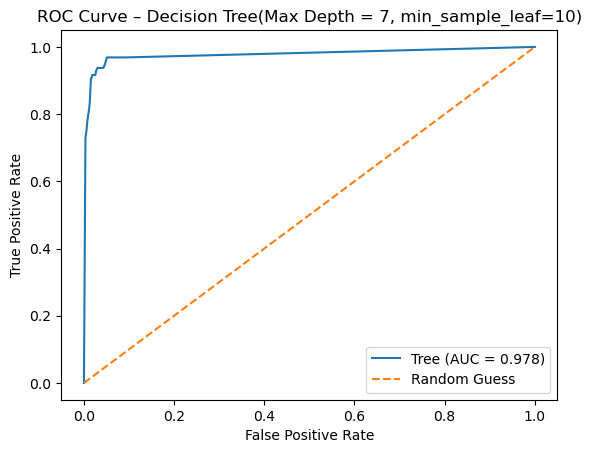

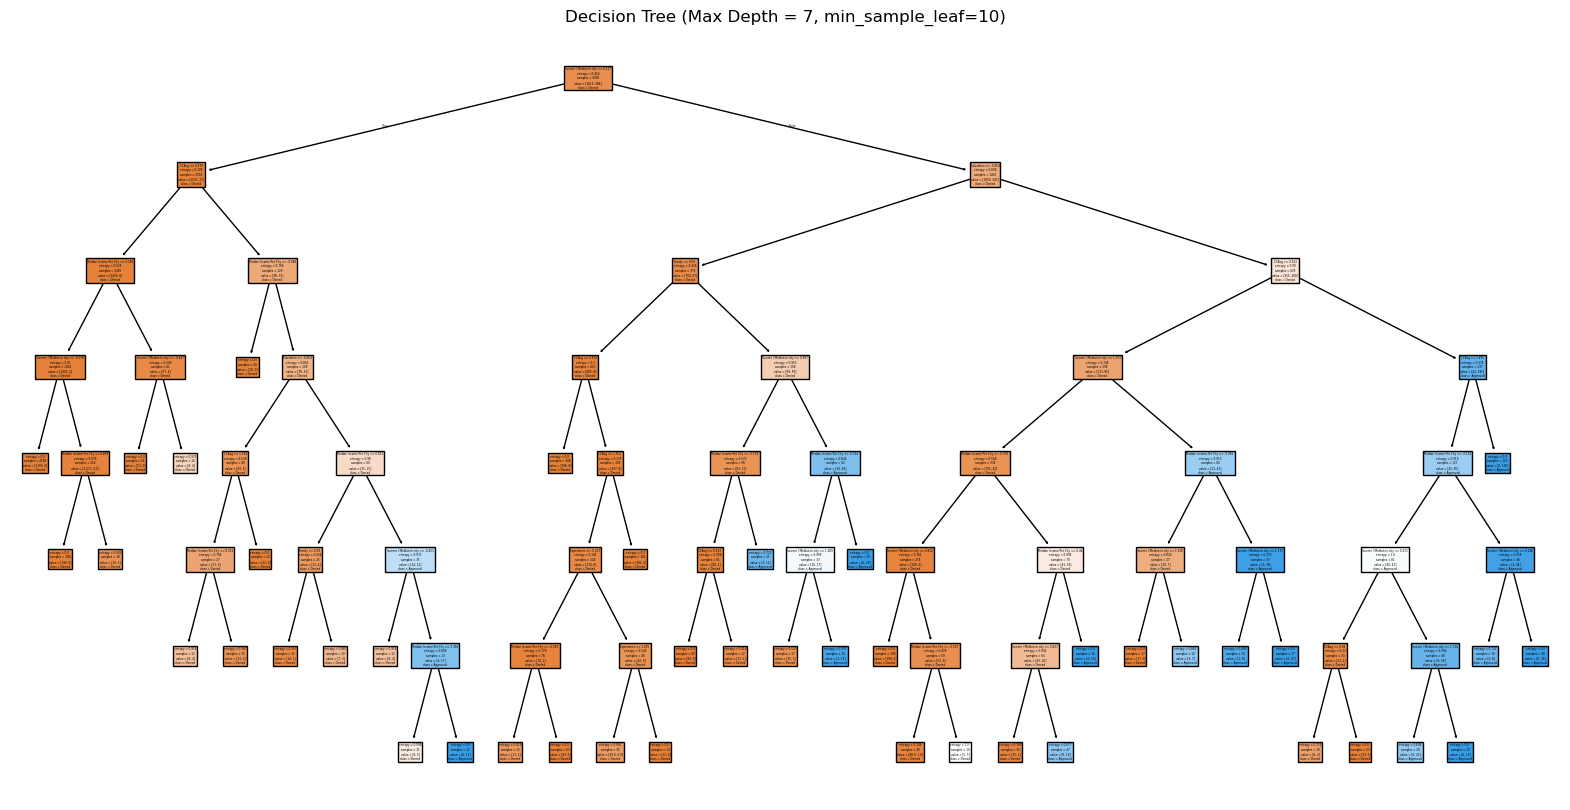

|--- Income / Median in city <= 0.12
|   |--- CCAvg <= 0.58
|   |   |--- Median Income Per City <= 2.46
|   |   |   |--- Income / Median in city <= -0.08
|   |   |   |   |--- weights: [2190.00, 0.00] class: 0
|   |   |   |--- Income / Median in city >  -0.08
|   |   |   |   |--- Median Income Per City <= 0.86
|   |   |   |   |   |--- weights: [196.00, 0.00] class: 0
|   |   |   |   |--- Median Income Per City >  0.86
|   |   |   |   |   |--- weights: [16.00, 2.00] class: 0
|   |   |--- Median Income Per City >  2.46
|   |   |   |--- Income / Median in city <= -0.45
|   |   |   |   |--- weights: [51.00, 0.00] class: 0
|   |   |   |--- Income / Median in city >  -0.45
|   |   |   |   |--- weights: [6.00, 4.00] class: 0
|   |--- CCAvg >  0.58
|   |   |--- Median Income Per City <= -0.05
|   |   |   |--- weights: [20.00, 0.00] class: 0
|   |   |--- Median Income Per City >  -0.05
|   |   |   |--- Education <= -0.45
|   |   |   |   |--- CCAvg <= 1.29
|   |   |   |   |   |--- Median Income P

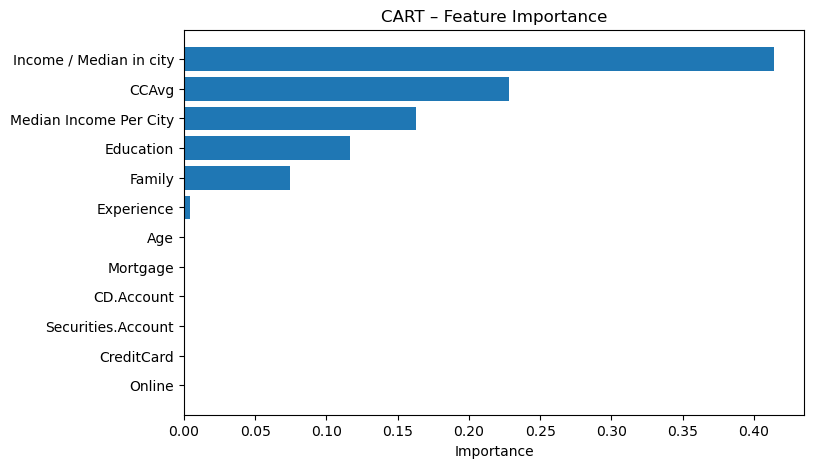

In [7]:
# Decision Tree Classifier – Loan Approval Prediction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, precision_score,
    roc_auc_score, roc_curve, confusion_matrix
)

# =========================
# 1. Load Data
# =========================
df = pd.read_excel("455 Data.xlsx")
df.columns = df.columns.str.strip()

# =========================
# 2. Variables
# =========================
target = "Personal.Loan"

predictors = [
    "Age",
    "Experience",
    "Family",
    "CCAvg",
    "Education",
    "Mortgage",
    "Securities.Account",
    "CD.Account",
    "Online",
    "CreditCard",
    "Median Income Per City",
    "Income / Median in city"
]

data = df[[target] + predictors].dropna()

X = data[predictors]
y = data[target]

# =========================
# 3. Train/Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# =========================
# 4. Decision Tree (Max Depth = 7)
# min_samples_leaf=10 — prevents fragile leaves based on few observations
# =========================
tree = DecisionTreeClassifier(
    max_depth=7,
    min_samples_leaf=10,
    criterion="entropy",
    random_state=42
)

tree.fit(X_train, y_train)
# =========================
# 5. Predictions
# =========================
y_pred = tree.predict(X_test)
y_prob = tree.predict_proba(X_test)[:, 1]

# =========================
# 6. Metrics
# =========================
accuracy  = accuracy_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
auc       = roc_auc_score(y_test, y_prob)

print("Decision Tree (Max Depth = 7, min_sample_leaf = 10)")
print("Accuracy:",  round(accuracy, 4))
print("Recall:",    round(recall, 4))
print("Precision:", round(precision, 4))
print("F1 Score:",  round(f1, 4))
print("AUC:",       round(auc, 4))





# =========================
# K-Fold Cross Validation
# 10-fold CV following Eissa's methodology — more reliable estimate
# of model performance than a single train/test split
# =========================
from sklearn.model_selection import KFold, cross_validate

kfold = KFold(10, shuffle=True, random_state=42)

cv_results = cross_validate(tree, X, y,
                            cv=kfold,
                            scoring='accuracy')

print("K-Fold CV (k=10)")
print("Mean CV Accuracy:", round(cv_results['test_score'].mean(), 4))
print("Std CV Accuracy:",  round(cv_results['test_score'].std(), 4))
# =========================
# 7. Confusion Matrix
# =========================
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(pd.DataFrame(cm,
                   index=["Actual: Denied", "Actual: Approved"],
                   columns=["Predicted: Denied", "Predicted: Approved"]))

# =========================
# 8. ROC Curve
# =========================
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"Tree (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Decision Tree(Max Depth = 7, min_sample_leaf=10)")
plt.legend()
plt.show()

# =========================
# 9. Plot Tree
# =========================
plt.figure(figsize=(20, 10))
plot_tree(
    tree,
    feature_names=predictors,
    class_names=["Denied", "Approved"],
    filled=True
)
plt.title("Decision Tree (Max Depth = 7, min_sample_leaf=10)")
plt.show()

# =========================
# 10. Text Representation
# =========================
print(export_text(tree, feature_names=predictors, show_weights=True))

# =========================
# 11. Feature Importance
# =========================
importance_df = pd.DataFrame({
    "Feature":    predictors,
    "Importance": tree.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nFeature Importances:")
print(importance_df.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Importance")
plt.title("CART – Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [8]:
#Overfitting Check 

print("Train Accuracy:", round(accuracy_score(y_train, tree.predict(X_train)), 4))
print("Test Accuracy:",  round(accuracy_score(y_test, y_pred), 4))

print("Train AUC:", round(roc_auc_score(y_train, tree.predict_proba(X_train)[:,1]), 4))
print("Test AUC:",  round(auc, 4))

#Train AUC vs Test AUC:
#Gap < 0.02 — no overfitting, model generalizes well
#Gap 0.02–0.05 — mild overfitting, acceptable
#Gap > 0.05 — overfitting, model memorizing training data

Train Accuracy: 0.982
Test Accuracy: 0.977
Train AUC: 0.9968
Test AUC: 0.9776


In [9]:
leaves = tree.tree_.n_node_samples[tree.tree_.children_left == -1]
print("Min leaf size:", min(leaves))
print("Max leaf size:", max(leaves))
print("Leaves with < 10 observations:", sum(leaves < 10))
print("Leaves with < 5 observations:", sum(leaves < 5))

Min leaf size: 10
Max leaf size: 2190
Leaves with < 10 observations: 0
Leaves with < 5 observations: 0


In [1]:
#Decision Tree (Max Depth = 5) (BASELINE)

#OBSERVING FEW OBSERVATION LEAVES
#USING: 
#leaves = tree.tree_.n_node_samples[tree.tree_.children_left == -1]
#print("Min leaf size:", min(leaves))
#print("Max leaf size:", max(leaves))
#print("Leaves with < 10 observations:", sum(leaves < 10))
#print("Leaves with < 5 observations:", sum(leaves < 5))

##OUTPUT##
#Min leaf size: 2
#Max leaf size: 2190
#Leaves with < 10 observations: 5
#Leaves with < 5 observations: 4

#================================================================================================

#METRICS
#Accuracy: 0.96
#Recall: 0.8646
#Precision: 0.7545
#F1 Score: 0.8058
#AUC: 0.9821

#OVERFIT CHECK
#Train Accuracy: 0.9647
#Test Accuracy: 0.96
#Train AUC: 0.9899
#Test AUC: 0.9821

#K-FOLD CROSS VALIDATION
#K-Fold CV (k=10)
#Mean CV Accuracy: 0.9644
#Std CV Accuracy: 0.0073

#Confusion Matrix:
 #                 Predicted: Denied  Predicted: Approved
#Actual: Denied                  877                   27
#Actual: Approved                 13                   83


NameError: name 'DecisionTreeClassifier' is not defined

In [ ]:
#Decision Tree (Max Depth = 5, min_samples_leaf = 10)   
#Accuracy: 0.959
#Recall: 0.8542
#Precision: 0.7523
#F1 Score: 0.8
#AUC: 0.9762

#Confusion Matrix:
                  #Predicted: Denied  Predicted: Approved
#Actual: Denied                  877                   27
#Actual: Approved                 14                   82

#Train Accuracy: 0.9625
#Test Accuracy: 0.959
#Train AUC: 0.9888
#Test AUC: 0.9762


In [ ]:
#Decision Tree (Max Depth = 3, min_samples_leaf = 10)
#Accuracy: 0.943
#Recall: 0.5208
#Precision: 0.8197
#F1 Score: 0.6369
#AUC: 0.9409

#Confusion Matrix:
 #                 Predicted: Denied  Predicted: Approved
#Actual: Denied                  893                   11
#Actual: Approved                 46                   50

#Train Accuracy: 0.9423
#Test Accuracy: 0.943
#Train AUC: 0.956
#Test AUC: 0.9409

In [ ]:
#Decision Tree (Max Depth = 7, min_samples_leaf = 10) (SELECTED)
#Accuracy: 0.977
#Recall: 0.9062
#Precision: 0.8614
#F1 Score: 0.8832
#AUC: 0.9776

#Confusion Matrix:
 #                 Predicted: Denied  Predicted: Approved
#Actual: Denied                  890                   14
#Actual: Approved                  9                   87

#Overfitting Check
#Train Accuracy: 0.982
#Test Accuracy: 0.977
#Train AUC: 0.9968
#Test AUC: 0.9776
